Path: ['S', 'B', 'F', 'G']


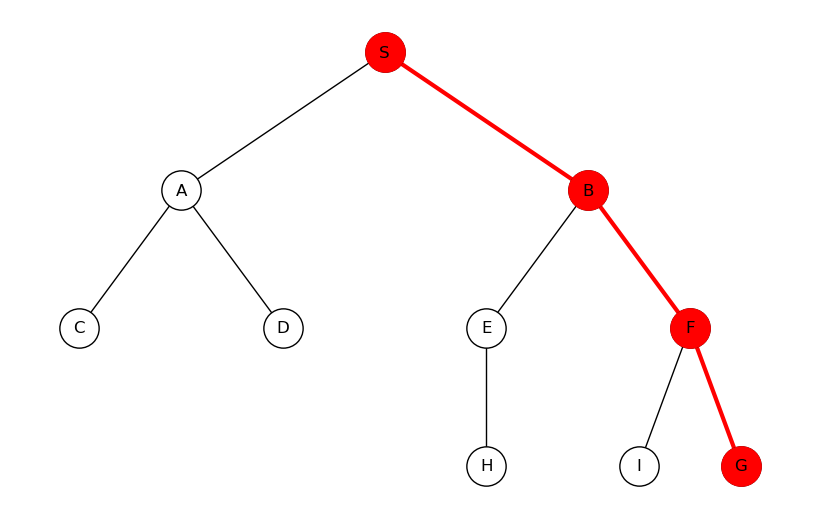

In [6]:
#PRACHI PILLAY AIDS A 14
from queue import PriorityQueue
import matplotlib.pyplot as plt
import networkx as nx

edges = [
    ('S', 'A'), ('S', 'B'), ('A', 'C'),
    ('A', 'D'),('B', 'E'),('B', 'F'),
    ('E', 'H'),('F', 'I'),('F', 'G')
]
heuristics = {
    'S': 10,'A': 7,'B': 4,
    'C': 8,'D': 6,'E': 3,
    'F': 1,'H': 4,'I': 2,'G': 0
}
positions = {
    'S': (0, 3),'A': (-2, 2), 'B': (2, 2),
    'C': (-3, 1),'D': (-1, 1), 'E': (1, 1),
    'F': (3, 1), 'H': (1, 0), 'I': (2.5, 0), 'G': (3.5, 0)
}

def gbfs(graph, start, goal, h_values):
    queue = PriorityQueue()
    queue.put((h_values[start], start, [start]))
    visited = set()
    while not queue.empty():
        _, current, path = queue.get()
        if current == goal:
            return path
        if current not in visited:
            visited.add(current)
            for nxt in graph.neighbors(current):
                if nxt not in visited:
                    queue.put(
                        (h_values[nxt], nxt, path + [nxt])
                    )
    return None
G = nx.Graph()
G.add_edges_from(edges)
path = gbfs(G, 'S', 'G', heuristics)
print("Path:", path)
plt.figure(figsize=(8, 5))
nx.draw(
    G,
    pos=positions,
    with_labels=True,
    node_color='white',
    edgecolors='black',
    node_size=800
)
nx.draw_networkx_nodes(
    G,
    pos=positions,
    nodelist=path,
    node_color='red',
    node_size=800
)
nx.draw_networkx_edges(
    G,
    pos=positions,
    edgelist=list(zip(path, path[1:])),
    edge_color='red',
    width=3
)
plt.show()